# Ejercicios Prácticos Módulo VI

La entrega será la copia de este notebook resuelta con el nombre del participante en el nombre del archivo.
* Recuerde copiar este notebook y trabajar sobre la copia.

## Opción 1

Realizar los 3 siguientes ejercicios, documentar paso a paso como es el proceso, imprimir el accuraccy y las imagenes resultantes de cada uno de ellos.

### Ejercicio 1

Hacer un clasificador de perros y gatos, definimos las imagenes de 180x180x1 y el número de clases es igual a 2, usar una arquitectura tipo lenet (Accuracy debe ser mayor al 70% para que se tome como completo).

#### Preparar ambiente

Durante la clase los ejercicios se realizaron utilizando keras y tensorflow, en mi caso tensorflow no es compatible con mi GPU que tiene un CUDA 13.2, estuve leyendo la documentación y tensorflow al parecer solo es compatible máximo con CUDA 12.x áun no tiene soporte para CUDA 13.x. Tomando en cuenta esto y para que yo pueda aprovechar el uso de mi GPU en el entrenamiento de los ejercicios, utilizaré PyTorch.

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [ ]:
!pip install torchinfo

Con el siguiente fragmento de código se puede comprobar si nuestro ambiente esta detectando la GPU.

In [14]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: True
GPU: NVIDIA GeForce RTX 2070 SUPER


In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchinfo import summary

Con este comando descargaremos el dataset de las imagenes de Perros y Gatos que utilizaremos para entrenar nuestro modelo

In [8]:
!curl -O https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  786M  100  786M    0     0  10.6M      0  0:01:13  0:01:13 --:--:-- 11.4MM      0  0:01:14  0:00:33  0:00:41 11.3M


Debemos descomprimir el archivo del dataset.

In [10]:
!unzip -q kagglecatsanddogs_5340.zip

In [16]:
!ls PetImages

Cat  Dog


El dataset de las imagenes que se descargo puede ser que contenga imagenes dañadas, por lo tanto es importante realizar una limpieza de nuestro dataset.
En este caso revisaremos imagen por imagen para saber cuales pudieran estar dañadas y en este caso las eliminamos, ya que no nos serán útiles.

In [12]:
num_deleted = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join("PetImages", folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        finally:
            fobj.close()
        
        if not is_jfif:
            num_deleted += 1
            # Borramos la imagen corrupta
            os.remove(fpath)

print(f"Imagenes eliminadas: {num_deleted}")

Imagenes eliminadas: 1590


El total de Imagenes eliminadas fue de: 1590, es por eso que es importante hacer una limpieza a nuestro dataset.

In [17]:
image_size = (180, 180) # Las instrucciones del ejercicio nos solicita definir las imagenes de 180x180
batch_size = 256 # Definimos el tamaño de nuestro batch, este realmente puede ser cualquiera, pero para aprovechar mi GPU será de 256

#Definimos nuestra semilla de aleatoridad.
seed = 26 # Me gusta el 26 jeje
torch.manual_seed(seed)
np.random.seed(seed)
generator = torch.Generator().manual_seed(seed)


# Definimos las transformaciones que se aplicarán a cada imagen de nuestro dataset
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Como el ejercicio pide que sea 180x180x1 el x1 del final hace referencia a escalas grises, actualmente nuestras imagenes son RGB x3
    transforms.Resize(image_size), # Redimensionamos todas las imagenesa a el tamaño definido 180x180
    transforms.ToTensor() # Se normalizan las imagenes automáticamente, tenemos un rango de [0, 255] y lo pasa a un rango de [0,1]
])

# Cargamos nuestro dataset
dataset = datasets.ImageFolder(
    root="PetImages", # Nombre de la carpeta que contiene el dataset, se toma cada subcarpeta que tengamso como una clase, en nuestro caso "Cats" -> Clase 0 y "Dogs" -> Clase 1
    transform=transform # Se aplican las transformaciones definidas anteriormente
)

train_size = int(0.8 * len(dataset)) # Definimos el tamaño de entrenamiento: 80%
val_size = len(dataset) - train_size # Defininimos el tamaño de validación: 20%

# Dividimos nuestro dataset de forma aleatoria: 80% para entrenamiento y 20% para validación
train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=generator)

# Creamos los DataLoader de entrenamiento y validación, estos permiten iterar sobre nuestro dataset en batches (128)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True) # Para el caso del entrenamiento mezclamos los datos en cada época 
                                                                         # (Para que no aprenda primero puros Gatos y luego puros Perros)
val_loader = DataLoader(val_ds, batch_size=batch_size)  # Para la validación no es necesario hacer una mezcla

In [18]:
# Definimos nuestro modelo para PyTorch, en clase lo definimos con keras.Sequential(), se me hace más intuitivo como lo maneja keras para ser sinceros.
# Para PyTorch se tiene que definir una clase en este caso definiremos nuestra CNN

class CNN(nn.Module):
    def __init__(self):
        # Definimos la clase padre
        super(CNN, self).__init__()

        # Capas convolucionales
        # Para crear la capa se utiliza Conv2d que recibe los siguientes parametros: Conv2d(entrada, salida, tamaño_kernel)

        self.conv1 = nn.Conv2d(1, 32, 3)    # Primera capa: Recibe un canal (Ya que estamos trabajando con imagenes en escalas grises) y produce 32 mapas de características. 
        self.conv2 = nn.Conv2d(32, 64, 3)   # Segunda capa: 32 -> 64 filtros
        self.conv3 = nn.Conv2d(64, 128, 3)  # Tercera capa: 64 -> 128 filtros
        self.conv4 = nn.Conv2d(128, 128, 3) # Cuarta capa: 128 -> 128 filtros

        self.pool = nn.MaxPool2d(2, 2)      # Capa de pooling (reduce el tamaño espacial), en clase vimos que puede ser de 2x2, 3x3, etc. Pero 2x2 en este caso es funcional

        self.fc1 = nn.Linear(128 * 9 * 9, 128)  # Capa densa, esta capa recibe el tensor aplanado (flatten)
        self.dropout = nn.Dropout(0.5)      # Con el dropout apagamos aleatoriamente neuronas para evitar overfitting
        self.fc2 = nn.Linear(128, 2)        # Capa final, esperamos una salida de 2 (Cat y Dog)

    # Definimos el orden de ejecución y sus funciones de activación para cada capa.
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # Aplicamos la primera capa de convolución, con una función de activación ReLU y realizamos el pooling
        x = self.pool(F.relu(self.conv2(x))) # Aplicamos la segunda capa de convolución, con una función de activación ReLU y realizamos el pooling
        x = self.pool(F.relu(self.conv3(x))) # Aplicamos la tercera capa de convolución, con una función de activación ReLU y realizamos el pooling
        x = self.pool(F.relu(self.conv4(x))) # Aplicamos la cuarta capa de convolución, con una función de activación ReLU y realizamos el pooling
        x = torch.flatten(x, 1) # Se realiza un flatten para aplanar y obtener un vector.
        x = F.relu(self.fc1(x)) # Aplicamos la capa densa, con una función de activación ReLU, aquí ya no hacemos pooling
        x = self.dropout(x) # Aplicamos dropout
        x = self.fc2(x) # Esta es nuestra capa final que tendra nuesta salida de 2 (Cat y Dog), en PyTorch no se acostumbra a poner la función de activiación Softmax en este flujo
                        # Posteriomente en el entrenamiento se utiliza CrossEntropyLoss que internamente realiza un Softmax.

        return x

In [22]:
# Y ahora si, la razón por la cual estoy utilizando PyTorch es para aprovechar mi GPU en el entrenamiento.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Detectamos si existe una GPU (CUDA)

model = CNN().to(device) # Enviamos el modelo para que se ejecute en CPU o GPU (En mi caso se va al GPU)

summary(model, input_size=(batch_size, 1, 180, 180)) # En keras teniamos algo como model.summary() para ver la info, en este caso se utiliza summary de torchinfo

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [256, 2]                  --
├─Conv2d: 1-1                            [256, 32, 178, 178]       320
├─MaxPool2d: 1-2                         [256, 32, 89, 89]         --
├─Conv2d: 1-3                            [256, 64, 87, 87]         18,496
├─MaxPool2d: 1-4                         [256, 64, 43, 43]         --
├─Conv2d: 1-5                            [256, 128, 41, 41]        73,856
├─MaxPool2d: 1-6                         [256, 128, 20, 20]        --
├─Conv2d: 1-7                            [256, 128, 18, 18]        147,584
├─MaxPool2d: 1-8                         [256, 128, 9, 9]          --
├─Linear: 1-9                            [256, 128]                1,327,232
├─Dropout: 1-10                          [256, 128]                --
├─Linear: 1-11                           [256, 2]                  258
Total params: 1,567,746
Trainable params: 1,567,746
Non-trainab

In [23]:
criterion = nn.CrossEntropyLoss() # Función de pérdida: Combina Softmax + Cálculo de error
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Para ajustar los pesos del modelo durante el entrenamiento, utilizaremos Adam (En clase se dijo que era el bueno)

In [ ]:
# Este fragmento de código sirve para entrenar nuestro modelo

epochs = 20 # Definimos el número de épocas

# En keras se utilizaba algo como model.fit(), en pytorch se tiene que hacer manualmente el entrenamiento
for epoch in range(epochs):
    model.train() # Debemos indicar que el modelo esta en entrenamiento para que active las capas especiales como Dropout
    
    # Inicializamos variables para obtener el loss y accuracy
    running_loss = 0.0
    correct = 0
    total = 0

    # Recorremos los datos en batches (train_loader contiene la info del batch)
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) # Aprovechamos una vez más la GPU enviandolo a que se ejecute ahí
        optimizer.zero_grad()   # Se reinician los gradientes
        outputs = model(images) # Obtenemos las predicciones del modelo (salidas)
        loss = criterion(outputs, labels)   # Calculamos la pérdida comparando las predicciones contras las etiquetas reales

        loss.backward() # Calcula los gradientes de la pérdida (Backpropagation)
        optimizer.step()  # Actualiza los pesos del modelo usando el optimizador Adam

        running_loss += loss.item() * images.size(0) # Acumulamos la pérdida del batch

        _, predicted = torch.max(outputs, 1) # Obtenemos la prediccion, devuelve en predicted el indice que tenga mayor valor (Cats -> 0 o Dogs -> 1)
        total += labels.size(0) # Contamos cuantas imagenes se procesaron en esta iteración (Lo normal es que sea de 256 por que es el tamaño de nuestro batch)
        correct += (predicted == labels).sum().item()  # Comparamos las predicciones con las etiquetas para saber cuantas predicciones fueron correctas y sumamos

    accuracy_epoch = correct / total  # Calculamos el accuracy total de la época
    loss_epoch = running_loss / total # Calculamos el loss total de la época

    print(f"Epoch {epoch+1}, Loss: {loss_epoch:.4f}, Accuracy: {accuracy_epoch:.4f}") # Imprimimos resultados de la época

Epoch 1, Loss: 0.6811, Accuracy: 0.5591
Epoch 2, Loss: 0.6429, Accuracy: 0.6341
Epoch 3, Loss: 0.5907, Accuracy: 0.6877
Epoch 4, Loss: 0.5465, Accuracy: 0.7252
Epoch 5, Loss: 0.4892, Accuracy: 0.7657
Epoch 6, Loss: 0.4542, Accuracy: 0.7884
Epoch 7, Loss: 0.4130, Accuracy: 0.8100
Epoch 8, Loss: 0.3884, Accuracy: 0.8272
Epoch 9, Loss: 0.3601, Accuracy: 0.8422
Epoch 10, Loss: 0.3411, Accuracy: 0.8485
Epoch 11, Loss: 0.3181, Accuracy: 0.8597
Epoch 12, Loss: 0.2893, Accuracy: 0.8759
Epoch 13, Loss: 0.2659, Accuracy: 0.8893
Epoch 14, Loss: 0.2378, Accuracy: 0.9016
Epoch 15, Loss: 0.2090, Accuracy: 0.9137
Epoch 16, Loss: 0.1865, Accuracy: 0.9221
Epoch 17, Loss: 0.1781, Accuracy: 0.9267
Epoch 18, Loss: 0.1465, Accuracy: 0.9420
Epoch 19, Loss: 0.1399, Accuracy: 0.9435
Epoch 20, Loss: 0.1202, Accuracy: 0.9526


In [25]:
# Este fragmento de código es para tomar el dataset de validación y obtener el accuracy y perdida de nuestro modelo, al enfrentarse a imagenes que no conoce.

model.eval() # Ahora debemos poner nuestro modelo en modo de evaluación

# Iniciamos variables para obtener el loss y accuracy
val_loss = 0.0
correct = 0
total = 0

with torch.no_grad(): # Desactivamos el cálculo de gradientes
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device) # Enviamos los datos a la GPU para aprovechar su rendimiento
        outputs = model(images) # Obtenemos las predicciones del modelo (salidas)
        loss = criterion(outputs, labels) # Calculamos la pérdida 
        val_loss += loss.item() * images.size(0)  # Acumlamos la pérdida 
        _, predicted = torch.max(outputs, 1)   # Obtenemos la prediccion, devuelve en predicted el indice que tenga mayor valor (Cats -> 0 o Dogs -> 1)
        total += labels.size(0) # Contamos cuantas imagenes se procesaron en esta iteración (Lo normal es que sea de 256 por que es el tamaño de nuestro batch)
        correct += (predicted == labels).sum().item() # Comparamos las predicciones con las etiquetas para saber cuantas predicciones fueron correctas y sumamos


val_loss = val_loss / total # Calculamos la pérdida total del dataset de validación
accuracy = correct / total # Calculamos el accuracy total del dataset de validación

print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {accuracy:.4f}")

Validation loss: 0.4975
Validation accuracy: 0.8475


#### Interpretación de los resultados obtenidos:

<b>* Validation loss de 0.4975</b>: Este entre más bajo sea es mejor, lo que podemos observar es que hay oportunidad para mejorar nuestro modelo, pero lo que indica es que tanto se acercan las predicciones del modelo a las predicciones reales. 

<b>* Validation accuracy de 0.8475</b>: Este entre más cercano al 1 mejor, pero lo que indica es que porcentaje de imágenes fueron correctamente clasificadas en el dataset de validación. Para la tarea se solicitaba que fuera arriba de 70% por lo que obtener un 84% es bastante bueno.

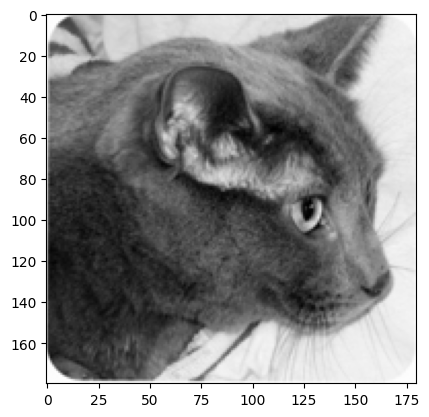

Esta imagen es 99.87% Gato y 0.13% Perro.


In [26]:
# Este fragmento de código es para realizar una prueba de predicción de una imagen con nuestro modelo.

# Cargar imagen en escala de grises con convert("L")
img = Image.open("PetImages/Cat/6779.jpg").convert("L")
img = img.resize((180, 180))

# Mostrar imagen
plt.imshow(img, cmap="gray")
plt.show()

# Preprocesar la imagen para poder ingresarla al modelo
img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)

# Predicción
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1) # Aquí lo que queremos es saber la predicción y no como tal saber el loss y accuracy. Por lo tanto metemos la función softmax a la salida de nuestra red.

# Convertir las probabilidades a numpy para asignarlas
probs = probs.cpu().numpy()[0]

gato_prob = probs[0]
perro_prob = probs[1]

print(f"Esta imagen es {100 * gato_prob:.2f}% Gato y {100 * perro_prob:.2f}% Perro.")

### Ejercicio 2

Crea una red que clasifique el dataset stanford_dogs usando el extractor del VGG16
1. Definir un modelo que tenga el VGG16 como entrada
2. Aplanar el vector de rasgos
3. Definir una o varias capas densas con 120 clases de salida
4. Entrenar el modelo

In [3]:
import torch
import os
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import kagglehub # Utilizaremos kaggle para descargar el dataset de standford_dogs

In [2]:
# Una vez más aprovecharé el uso de mi GPU para el entrenamiento de este ejercicio
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU: NVIDIA GeForce RTX 2070 SUPER


In [5]:
# Durante clase el dataset lo descargamos con tensorflow_datasets, sin embargo como yo estoy utilizando pyTorch la alternativa es descargalo mediante kaggle.
path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset") # El dataset en kaggle tiene la misma información: 120 clases y 20,580 imagenes
print("Dataset descargado en:", path) # Kaggle almacena los dataset en una carpeta de cache para poder reutilizarlo y que no se descargue cada que ejecutamos el código.

Dataset descargado en: /home/ismael/.cache/kagglehub/datasets/jessicali9530/stanford-dogs-dataset/versions/2


In [6]:
# Revisando la ruta donde se descargo el dataset de Kaggle, las imagenes se encuentran en path/images/Images/
# Dentro de esta carpeta las 120 clases se encuentran en subcarpetas
train_dir = os.path.join(path, "images", "Images") # Obtenemos la ruta donde se encuentran las carpetas de las 120 clases

IMG_SIZE = 224 # Definimos el tamaño de imagen que utilizaremos para entrenar el modelo en nuestro caso VGG16 requiere imagenes 224x224

# Definimos las transformaciones que se aplicarán a cada imagen de nuestro dataset
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # Redimensionamos todas las imagenes a el tamaño definido 224x224
    transforms.RandomHorizontalFlip(), # Voltea imagenes aleatoriamente 
    transforms.RandomRotation(15), # Rota ligeramente las imagenes aleatoriamente
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Cambiamos ligeramente brillo y contraste aleatoriamente
    transforms.ToTensor(), # Convierte la imagen a un tensor de PyTorch y escala los valores de [0,255] a un rango de [0,1]
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]) # Esta normalización la obtuve de internet, recomiendan hacerlo ya que VGG16 fue entrenando con ese rango de valores para el canal de RGB
])

# Definimos las transformaciones que se aplicarán a las imagenes del dataset de validación, ya que para el dataset de validacion no ocupamos data augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # Redimensionamos todas las imagenes a el tamaño definido 224x224
    transforms.ToTensor(), # Convierte la imagen a un tensor de PyTorch y escala los valores de [0,255] a un rango de [0,1]
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]) # Esta normalización la obtuve de internet, recomiendan hacerlo ya que VGG16 fue entrenando con ese rango de valores para el canal de RGB
])

full_dataset = ImageFolder(train_dir) # Cargamos el dataset que descargamos de Kaggle

NUM_CLASSES = len(full_dataset.classes) # Obtenemos el número total de clases solo para validar que se haya importado correctamente
print("Número de clases:", NUM_CLASSES)

Número de clases: 120


In [7]:
# En este fragmento de código prepararemos nuestro dataset de entrenamiento y dataset de validación

train_size = int(0.8 * len(full_dataset)) # Definimos el tamaño de entrenamiento: 80%
val_size = len(full_dataset) - train_size # Definimos el tamaño de validación: 20%

# Generamos indices aleatorios para dividir el dataset
train_indices, val_indices = torch.utils.data.random_split(range(len(full_dataset)), [train_size, val_size])

train_dataset = ImageFolder(train_dir, transform=train_transform) # Creamos el dataset de entrenamiento, el cual contiene las transformaciones de data augmentation
val_dataset = ImageFolder(train_dir, transform=val_transform) # Creamos el dataset de validación sin transformaciones de augmentation

train_ds = torch.utils.data.Subset(train_dataset, train_indices.indices) # Aplicamos al dataset solo los indices correspondientes a nuestro entrenamiento
val_ds   = torch.utils.data.Subset(val_dataset, val_indices.indices) # Aplicamos al dataset solo los indices correspondientes a nuestra validación

In [8]:
batch_size = 32 # Definimos el tamaño de nuestro batch, este realmente puede ser cualquiera, pero para aprovechar mi GPU será de 32 ya que lo haremos con 4 workers

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4) # Para el caso del entrenamiento mezclamos los datos en cada época 
                                                                                        # num_workers es para definir la cantidad de procesos paralelos al momento de cargar datos
val_loader  = DataLoader(val_ds, batch_size=batch_size, num_workers=4) # Para validación no se debe hacer shuffle

In [24]:
# Cargamos el modelo VGG16 preentenado con ImageNet
# La estructura interna del modelo es más o menos así:
# model = nn.Sequential(
#   model.features,     -> Convoluciones
#   model.avgpool,      -> Pooling
#   nn.Flatten(),       -> Se obtiene el vector con flatten
#   model.classifier    -> Capas finales para clasificar y obtener nuestra salida
# )

# En clase utilizamos keras para cargar el modelo algo como:
# base_model = VGG16(weights='imagenet', include_top=False, input_shape=(180, 180, 3))
# En el cual le indicabamos que no queriamos la parte superior de la red con include_top
# En este caso con PyTorch más adelante en el código sobreescribiremos esta parte superior de la red
# la cual hace referencial al model.classifier

model = models.vgg16(weights="IMAGENET1K_V1")

In [25]:
# Dado que el modelo VGG16 ya esta preentrenado, no queremos modificar los pesos de las capas convolucionales.
# Por lo tanto las congelamos con el siguiente ciclo.
for param in model.features.parameters():
    param.requires_grad = False

In [26]:
# Retomando el comentario anterior sobre sobreescribir la parte superior del modelo, en este fragmento lo realizaremos.
# La parte superior del modelo es el classifier, por lo tanto lo modificamos para que se ajuste a nuestras salidas que son 120.

model.classifier = nn.Sequential(
    nn.Linear(25088, 512), # Capa densa que recibe como entrada el resultado del Flatten del VGG16
    nn.ReLU(), # Incluimos una relu como función de activiación
    nn.Dropout(0.5), # Apagamos aleatoriamente el 50% de las neuronas en el entrenamiento
    nn.Linear(512, NUM_CLASSES) # Nuestra capa final de clasificación, para que nuestro modelo tenga una salida de 120 clases
)

In [27]:
model = model.to(device) # Enviamos el modelo a la GPU para aprovecharla

In [28]:
criterion = nn.CrossEntropyLoss() # Función de pérdida: Combina Softmax + Cálculo de error
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001) # Para ajustar los pesos del modelo durante el entrenamiento, utilizaremos Adam (En clase se dijo que era el bueno)

In [ ]:
# Este fragmento de código sirve para entrenar nuestro modelo
epochs = 30 # Definimos el número de épocas, puede ser cualquiera, pero para este caso que tenemos un mayor número de clases en el dataset decidí aumentar a 30 épocas

# En keras se utilizaba algo como model.fit(), en pytorch se tiene que hacer manualmente el entrenamiento
for epoch in range(epochs):
    model.train() # Debemos indicar que el modelo esta en entrenamiento para que active las capas especiales como Dropout

    # Inicializamos variables para obtener el loss y accuracy
    running_loss = 0.0
    correct = 0
    total = 0

    # Recorremos los datos en batches (train_loader contiene la info del batch)
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) # Aprovechamos una vez más la GPU enviandolo a que se ejecute ahí
        optimizer.zero_grad() # Se reinician los gradientes
        outputs = model(images) # Obtenemos las predicciones del modelo (salidas)
        loss = criterion(outputs, labels)  # Calculamos la pérdida comparando las predicciones contras las etiquetas reales
        loss.backward() # Calcula los gradientes de la pérdida (Backpropagation)
        optimizer.step() # Actualiza los pesos del modelo usando el optimizador Adam

        running_loss += loss.item() * images.size(0) # Acumulamos la pérdida del batch
        
        _, predicted = torch.max(outputs, 1) # Obtenemos la prediccion, devuelve en predicted el indice que tenga mayor valor de nuestras 120 clases
        total += labels.size(0) # Contamos cuantas imagenes se procesaron en esta iteración
        correct += (predicted == labels).sum().item() # Comparamos las predicciones con las etiquetas para saber cuantas predicciones fueron correctas y sumamos
    
    loss_epoch = running_loss / total # Calculamos el loss total de la época
    accuracy_epoch = correct / total  # Calculamos el accuracy total de la época

    print(f"Epoch {epoch+1}, Loss: {loss_epoch:.4f}, Accuracy: {accuracy_epoch:.4f}") # Imprimimos resultados de la época

Epoch 1, Loss: 3.3672, Accuracy: 0.2065
Epoch 2, Loss: 2.5365, Accuracy: 0.3203
Epoch 3, Loss: 2.3769, Accuracy: 0.3640
Epoch 4, Loss: 2.3037, Accuracy: 0.3790
Epoch 5, Loss: 2.2368, Accuracy: 0.3911
Epoch 6, Loss: 2.1979, Accuracy: 0.4001
Epoch 7, Loss: 2.1777, Accuracy: 0.4083
Epoch 8, Loss: 2.1571, Accuracy: 0.4142
Epoch 9, Loss: 2.1277, Accuracy: 0.4176
Epoch 10, Loss: 2.1076, Accuracy: 0.4237
Epoch 11, Loss: 2.0972, Accuracy: 0.4322
Epoch 12, Loss: 2.0725, Accuracy: 0.4350
Epoch 13, Loss: 2.0868, Accuracy: 0.4336
Epoch 14, Loss: 2.0185, Accuracy: 0.4515
Epoch 15, Loss: 2.0248, Accuracy: 0.4434
Epoch 16, Loss: 2.0240, Accuracy: 0.4517
Epoch 17, Loss: 2.0032, Accuracy: 0.4591
Epoch 18, Loss: 2.0045, Accuracy: 0.4555
Epoch 19, Loss: 1.9822, Accuracy: 0.4666
Epoch 20, Loss: 1.9912, Accuracy: 0.4565
Epoch 21, Loss: 1.9271, Accuracy: 0.4795
Epoch 22, Loss: 2.0089, Accuracy: 0.4633
Epoch 23, Loss: 2.0012, Accuracy: 0.4648
Epoch 24, Loss: 1.9473, Accuracy: 0.4789
Epoch 25, Loss: 1.9788, A

In [ ]:
# Este fragmento de código es para tomar el dataset de validación y obtener el accuracy y perdida de nuestro modelo, al enfrentarse a imagenes que no conoce.
model.eval() # Ahora debemos poner nuestro modelo en modo de evaluación

# Iniciamos variables para obtener el loss y accuracy
val_loss = 0.0
correct = 0
total = 0

with torch.no_grad(): # Desactivamos el cálculo de gradientes
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)  # Enviamos los datos a la GPU para aprovechar su rendimiento
        outputs = model(images) # Obtenemos las predicciones del modelo (salidas)
        loss = criterion(outputs, labels) # Calculamos la pérdida 
        val_loss += loss.item() * images.size(0)  # Acumlamos la pérdida 
        _, predicted = torch.max(outputs, 1) # Obtenemos la prediccion, devuelve en predicted el indice que tenga mayor valor de nuestras 120 clases
        total += labels.size(0) # Contamos cuantas imagenes se procesaron en esta iteración
        correct += (predicted == labels).sum().item() # Comparamos las predicciones con las etiquetas para saber cuantas predicciones fueron correctas y sumamos


val_loss = val_loss / total # Calculamos la pérdida total del dataset de validación
accuracy = correct / total # Calculamos el accuracy total del dataset de validación

print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {accuracy:.4f}")

Validation loss: 1.6888
Validation accuracy: 0.6166


#### Interpretación de los resultados obtenidos:

<b>* Validation loss de 1.6888</b>: Este entre más bajo sea es mejor, lo que podemos observar es que hay oportunidad para mejorar nuestro modelo, pero indica que tanto se acercan las predicciones del modelo a las predicciones reales. 

<b>* Validation accuracy de 0.6166</b>: Este entre más cercano al 1 mejor, pero lo que indica es que porcentaje de imágenes fueron correctamente clasificadas en el dataset de validación. Esto quiere decir que con el dataset de validación obtuvimos un 61%.

<b>* Nota</b>: Me llamo la atención que para este ejercicio los resultados de loss y accuracy en el entrenamiento fueron más bajos en la época 30 Loss: 1.9400, Accuracy: 0.4754, pero analizando supuse que se debe a que como en el entrenamiento estamos haciendo data augmentation (voltear, rotar, modificar el brillo y contrataste) en las imagenes esto hacía que las métricas del entrenamiento se vieran afectadas ya que es más díficil para el modelo hacer una buena predicción si se le estan presentando las imagenes en diferentes formas. Sin embargo cuando obtuvimos las métricas del dataset de validación que no contiene las transformaciones de data augmentation, los resultados de las métricas fueron mejores.

<b>* Conclusión</b>: Creo que los resultados obtenidos fueron bastantes buenos para el número de épocas que le dimos al entrenamiento, ya que este dataset que contiene 120 clases se vuelve más complejo. 

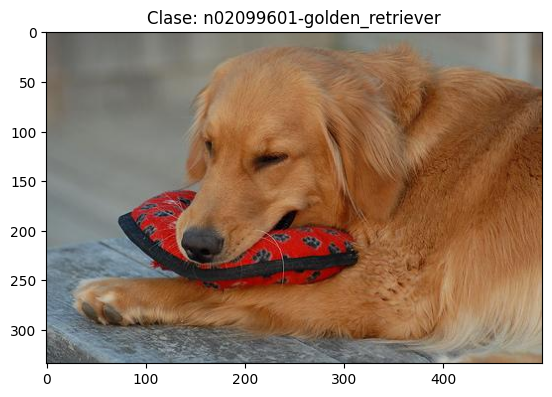

Clase de la predicción: n02099601-golden_retriever
Valor de predicción: 0.9993


In [46]:
# Este fragmento de código es para realizar una prueba de predicción de una imagen con nuestro modelo.
class_names = full_dataset.classes # Obtenemos todas las clases de nuestro dataset para saber el nombre de la clase que se predijo más adelante

class_label_image = 'n02099601-golden_retriever' # Seleccionamos una clase que queramos poner a prueba, en este caso yo elegí esta pero puede ser cualquiera.

img_path = os.path.join(path,"images","Images",class_label_image,"n02099601_10.jpg") # Ingrese a las carpetas manualmente para elegir una imagen. 

img = Image.open(img_path).convert("RGB") # Cargamos la imagen y la abrimos en formato RGB que es el que necesitamos

plt.imshow(img) # Mostramos una figura con la imagen que estamos evaluando
plt.title(f"Clase: {class_label_image}")  # Mostramos la clase que sabemos que es la imagen, esta no es la predicha por el modelo, es como esta etiquetada
plt.show() 

input_tensor = val_transform(img).unsqueeze(0).to(device) # Le realizamos las transformaciones correspondientes a la imagen con val_transform para que sea compatible con nuestro modelo.

# Predicción
model.eval()
with torch.no_grad():
    output = model(input_tensor)
    probs = torch.softmax(output, dim=1).cpu().numpy()[0] # Aquí lo que queremos es saber la predicción y no como tal saber el loss y accuracy. Por lo tanto metemos la función softmax a la salida de nuestra red.

pred_class = np.argmax(probs) # Obtenemos el indice de la clase que contenga el valor máximo, ya que este es el que estaría prediciendo.

print(f"Clase de la predicción: {class_names[pred_class]}") # La clase de la predicción
print(f"Valor de predicción: {probs[pred_class]:.4f}") # El valor de la predicción 

Probé con diferentes imagenes para la comprobación de los resultados y la verdad es que en la mayoría de los casos el modelo predice bien la clase, solo en aquellas clases donde la raza de perros es muy parecida es donde de repente se llega a equivocar. Pero en general el modelo tiene un buen desempeño para predecir las imagenes de las 120 clases.

### Ejercicio 3

YOLO
* Hacer un dataset de 100 imágenes con 3 clases
* Entrenar el modelo usando el dataset ya sea con la implementación de keras o la de ultralytics, se recomienda ultralytics.
* Entrenar el modelo y mostrar los resultados.

In [ ]:
!pip install ultralytics

In [ ]:
!pip install roboflow

#### Dataset para detectar personajes de Mario Bros (Mario, Luigi y Wario)

Descargue un total de 100 imagenes de internet que contuvieran personajes de Mario Bros, en especial a Mario, Luigi y Wario. En algunas de las imagenes se tienen a los 3 al mismo tiempo, en otros a 2 de ellos y en algunas la imagen es solamente 1 personaje. 

Posteriormente cargue las 100 imagenes y las subí a Roboflow para poder etiquetarlas, la forma en que las etiquete fue por cajas (Boxes), manualmente fui etiquetando cada una de las imagenes. 

Entonces lo que queremos lograr en que con YOLO podamos identificar a estos 3 personajes. 

Para contexto por si no se conocen estos personajes la forma de identificarlos es:
* <b>Mario</b>: El color rojo destaca y contiene una M en su sombrero
* <b>Luigi</b>: El color verde destaca y contiene una L en su sombrero
* <b>Wario</b>: El color amarillo destaca y contiene una W en su sombrero

Utilizaré <b>ultralytics</b> para entrenar mi modelo.

Desde roboflow se puede importar nuestro dataset para que se descargue en nuestro ambiente. 

El modelo que se eligió fue Yolov8.

Se descargará una carpeta con el nombre del dataset en este caso "Detección-de-personajes-SMB-1"

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="") # Teste el apikey ya que no debo exponerla directamente en github
project = rf.workspace("ismaels-workspace-skla6").project("deteccion-de-personajes-smb")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


Debemos importar YOLO de ultralytics.

In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

Dentro de la carpeta de la descarga de nuestro dataset de roboflow se debe encontrar un archivo llamado <b>data.yaml</b> este archivo es como un json que le indicara a nuestro modelo cuantas clases tenemos y cuales son las rutas de nuestro dataset de entrenamiento, validación y test.

Cuando se descargo el proyecto de roboflow, la carpeta debe contener internamente esta estructura:

```text
Detección-de-personajes-SMB-1/
│
├── train/
│   ├── images/
│   └── labels/
│
├── valid/
│   ├── images/
│   └── labels/
│
├── test/
│   ├── images/
│   └── labels/
│
└── data.yaml
```

Entonces ahora si llego el momento de entrenar a nuestro modelo, se utiliza el archivo data.yaml y se le indican el número de épocas en este caso elegí 50.

#### Entrenamiento

In [5]:
model.train(data="Detección-de-personajes-SMB-1/data.yaml", epochs=50)

Ultralytics 8.4.26 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2070 SUPER, 8192MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Detección-de-personajes-SMB-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ee7403f8fb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

#### Resultados de entrenamiento/validación

Una vez que nuestro modelo ya fue entrenado, se crea una carpeta de <b>runs</b>, en esa carpeta se encuentran diferentes archivos de los resultas y métricas del entrenamiento del modelo.

Mostraré 2 de los que considero que son los más importantes <b>results.png</b> y <b>confusion_matrix.png</b>

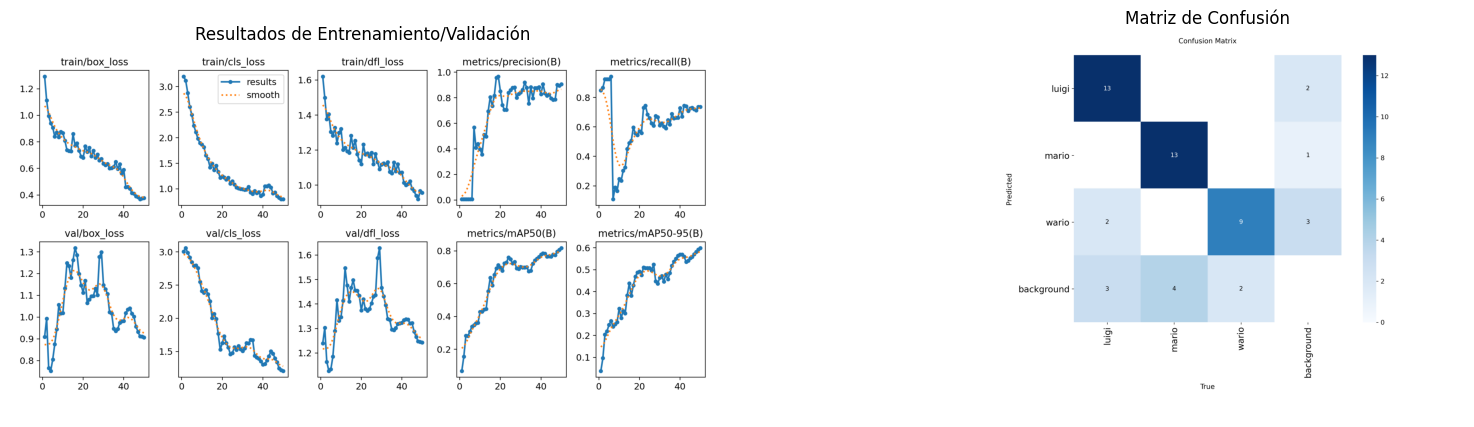

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

results = Image.open("../runs/detect/train/results.png")
confusion_matrix = Image.open("../runs/detect/train/confusion_matrix.png")

fig, axes = plt.subplots(1, 2, figsize=(20,5))

axes[0].imshow(results)
axes[0].set_title("Resultados de Entrenamiento/Validación")
axes[0].axis('off')

axes[1].imshow(confusion_matrix)
axes[1].set_title("Matriz de Confusión")
axes[1].axis('off')

plt.show()

Al realizar el entrenamiento YOLO automáticamente toma el dataset de entrenamiento y validación. 

Por lo que en los resultados se ve reflejado las métricas de entrenamiento y validación. 

En general podemos ver que la gráfica de LOSS va bajando progresivamente lo que indica que el modelo esta aprendiendo corrrectamente. 

La gráfica de precisión  y recall fue alrededor de 0.9 lo que indica que casi siempre el modelo es correcto.

En cuanto a la Matriz de confusión la diagonal principal que representa los aciertos para Mario, Luigi y Wario es bastante buena, el modelo aprendió a distinguir correctamente en la mayoría de los casos.

#### Prueba del modelo

Cómo pudimos ver anteriormente y que algo que descubrí es que efectivamente YOLO utiliza el dataset de entrenamiento y validación durante el entrenamiento, por lo que para poder evaluar nuestro modelo utilizaré el dataset de test. 

In [7]:
model.val(data="Detección-de-personajes-SMB-1/data.yaml", split="test")

Ultralytics 8.4.26 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2070 SUPER, 8192MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 192.8±64.9 MB/s, size: 63.0 KB)
val: Scanning /home/ismael/Documentos/DiplomadoIA/ModuloVI/Detección-de-personajes-SMB-1/test/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 3.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.1it/s 0.3s
                   all         10         17      0.973      0.944      0.987      0.758
                 luigi          7          7      0.975          1      0.995      0.611
                 mario          6          6      0.973      0.833      0.972      0.731
                 wario          4          4      0.971          1      0.995      0.933
Speed: 1.1ms preprocess, 2.9ms inference, 0.0ms loss, 1.0ms postprocess

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7407448b2780>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

#### Resultados del dataset de test

En la matriz de confusión resultante del dataset de prueba podemos ver que la diagonal principal se mantiene identificando correctamente en la mayoría de los casos a Mario, Luigi y Wario.

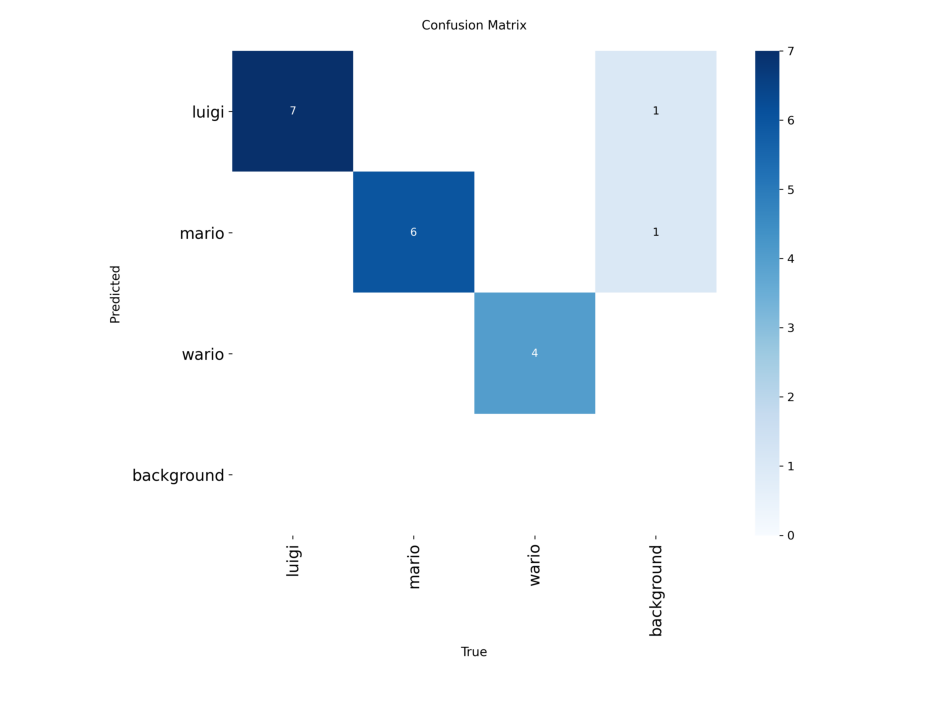

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

confusion_matrix = Image.open("../runs/detect/val/confusion_matrix.png")

plt.figure(figsize=(12, 10)) 
plt.imshow(confusion_matrix)
plt.axis('off')
plt.show()

#### Resultados de la detección de los personajes en las imagenes

Aunque ya evaluamos el modelo con nuestro dataset de test, quisé ponerlo a que hiciera una predicción sobre estas imagenes y guaradar los resultados para poder visualizar los resultados directamente en los ejemplos

In [ ]:
model.predict("Detección-de-personajes-SMB-1/test/images/", save=True)

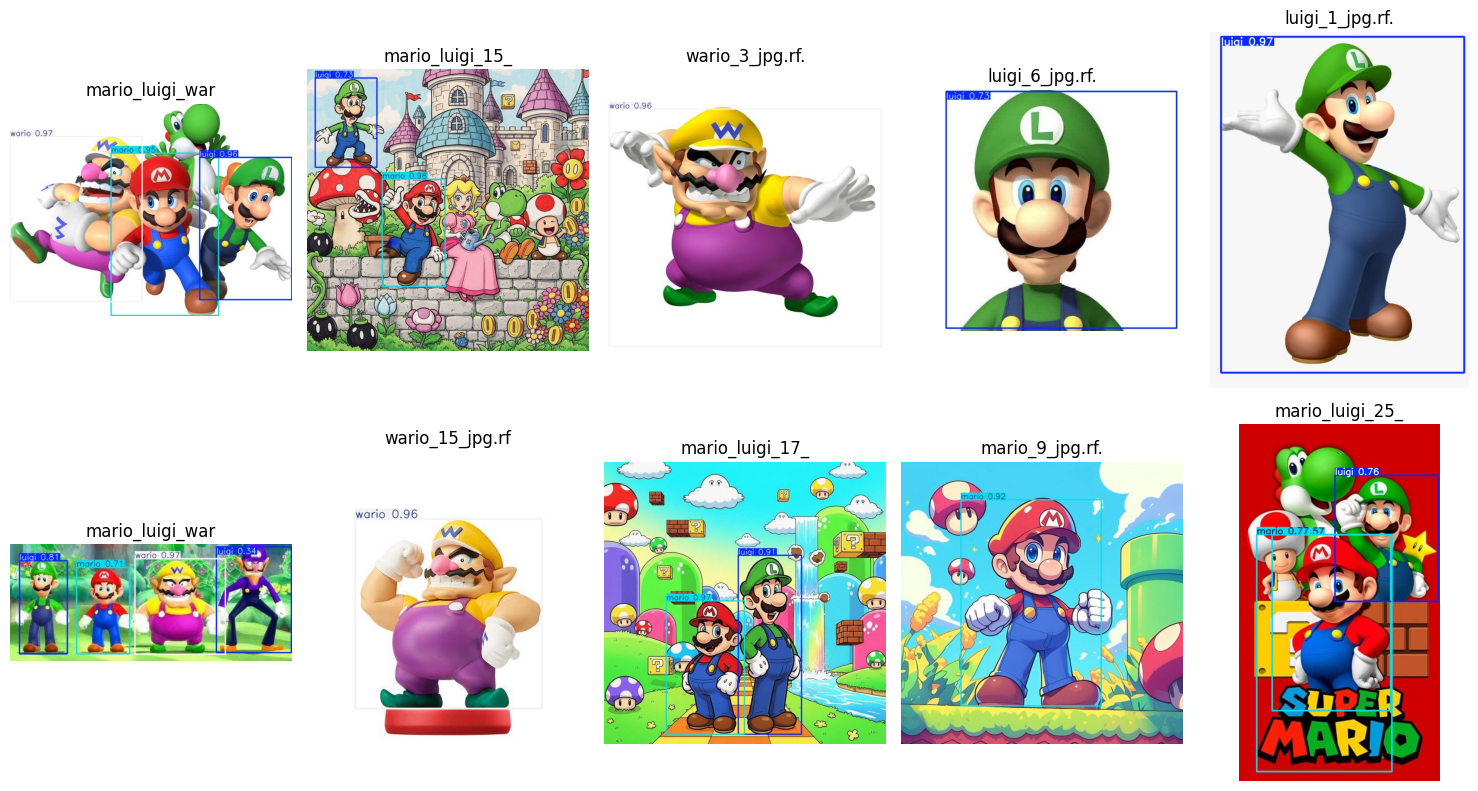

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

ruta = "../runs/detect/predict/"

imagenes = [img for img in os.listdir(ruta) if img.endswith(".jpg")]

cols = 5
rows = (len(imagenes) + cols - 1) // cols

plt.figure(figsize=(15, 8))

for i, img_name in enumerate(imagenes):
    img_path = os.path.join(ruta, img_name)
    img = Image.open(img_path)
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(img_name[:20])
    plt.axis('off')

plt.tight_layout()
plt.show()

Como podemos ver el modelo si aprendió a identificar los personajes de Mario, Luigi y Wario de forma correcta, incluso con diferentes estilos de animación. 


Por lo que podemos decir que nuestro modelo funciona muy bien.

Un dato curioso es que en una de las imagenes se muestra el personaje llamado Waluigi que en la historia del juego es como el primo malvado de Luigi o muchos tambien dicen que es el alterego de Luigi (así como Wario es el alterego de Mario). Lo curioso fue que el modelo no fue entrenado para identificar a Waluigi y lo qu eme llamo la atención fue que detecto un 34% de probabilidad de ser Luigi. 

Fue muy entretenido hacer este ejrcicio, pero sin duda alguna lo más talachudo es recopilar las imagenes y posteriormente el etiquetado. (aunque con roboflow ya es muy sencillo).